En psicología se estudián los rasgos de personalidad y el comportamiento humano. Para ello se usan datos, como pueden ser los que se recopilan a través del modelo de los cinco grandes rasgos de la personalidad.


Según este modelo la mayoría de los rasgos de la personalidad humana pueden resumirse en cinco grandes dimensiones universales, aplicables a cualquier idioma o cultura:



*   Apertura Mental (atributos OPN1 a OPN10)
*   Responsabilidad (atributos CSN1 a CSN10)
*   Extroversión (atributos EXT1 a EXT10)
*   Amabilidad (atributos AGR1 a AGR10)
*   Emocionalidad Negativa (atributos EST1 a EST10)

Estas cinco dimensiones surgieron de estudios en los que se realizaron cientos de preguntas a miles de personas.

https://www.kaggle.com/datasets/tunguz/big-five-personality-test

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/SAA/personality.csv", sep='\t')

In [4]:
df.shape

(1015341, 110)

# Muestreo

In [5]:
# Como partimos de tantos datos, para simplificar vamos a reducir
df_r = pd.DataFrame(df.sample(n = 5000))

In [6]:
df_r.shape

(5000, 110)

# Preparación de datos

## Eliminación de atributos

In [7]:
df_r.head()

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,dateload,screenw,screenh,introelapse,testelapse,endelapse,IPC,country,lat_appx_lots_of_err,long_appx_lots_of_err
364189,2.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,...,2017-03-04 22:08:09,360.0,640.0,3.0,223.0,15,1,MX,19.4342,-99.1386
643435,4.0,1.0,4.0,4.0,4.0,1.0,0.0,2.0,4.0,4.0,...,2018-03-07 16:27:58,1280.0,800.0,1184.0,97.0,7,31,US,38.0,-97.0
149321,1.0,5.0,3.0,3.0,1.0,2.0,1.0,4.0,2.0,4.0,...,2016-07-06 13:13:23,1920.0,1080.0,55783.0,135.0,90,1,US,38.864,-77.1922
5452,2.0,4.0,3.0,3.0,3.0,3.0,3.0,4.0,4.0,2.0,...,2016-03-07 04:46:02,1366.0,768.0,2.0,1419.0,57,1,MO,22.1667,113.55
119911,3.0,2.0,4.0,2.0,5.0,2.0,4.0,1.0,1.0,1.0,...,2016-06-03 07:46:03,1680.0,1050.0,5.0,304.0,19,1,US,29.9988,-95.2622


Los primeros 50 atributos se corresponden a preguntas del test y la contestación es una escala del 1 al 5 (1=Disagree, 3=Neutral, 5=Agree)

In [8]:
# Nos quedamos con los 50 primeros atributos, que son los que se corresponden a las preguntas del test
df_r.drop(df.columns[50:], axis=1, inplace=True)

In [9]:
df_r.head()

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,OPN1,OPN2,OPN3,OPN4,OPN5,OPN6,OPN7,OPN8,OPN9,OPN10
364189,2.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,...,3.0,3.0,3.0,4.0,3.0,2.0,3.0,2.0,3.0,3.0
643435,4.0,1.0,4.0,4.0,4.0,1.0,0.0,2.0,4.0,4.0,...,5.0,2.0,4.0,1.0,4.0,2.0,2.0,4.0,4.0,4.0
149321,1.0,5.0,3.0,3.0,1.0,2.0,1.0,4.0,2.0,4.0,...,2.0,1.0,5.0,1.0,5.0,1.0,4.0,1.0,5.0,4.0
5452,2.0,4.0,3.0,3.0,3.0,3.0,3.0,4.0,4.0,2.0,...,2.0,3.0,3.0,3.0,3.0,3.0,4.0,2.0,4.0,3.0
119911,3.0,2.0,4.0,2.0,5.0,2.0,4.0,1.0,1.0,1.0,...,3.0,1.0,4.0,2.0,3.0,2.0,4.0,1.0,3.0,3.0


## Valores nulos

In [10]:
df_r.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 364189 to 612724
Data columns (total 50 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   EXT1    4990 non-null   float64
 1   EXT2    4990 non-null   float64
 2   EXT3    4990 non-null   float64
 3   EXT4    4990 non-null   float64
 4   EXT5    4990 non-null   float64
 5   EXT6    4990 non-null   float64
 6   EXT7    4990 non-null   float64
 7   EXT8    4990 non-null   float64
 8   EXT9    4990 non-null   float64
 9   EXT10   4990 non-null   float64
 10  EST1    4990 non-null   float64
 11  EST2    4990 non-null   float64
 12  EST3    4990 non-null   float64
 13  EST4    4990 non-null   float64
 14  EST5    4990 non-null   float64
 15  EST6    4990 non-null   float64
 16  EST7    4990 non-null   float64
 17  EST8    4990 non-null   float64
 18  EST9    4990 non-null   float64
 19  EST10   4990 non-null   float64
 20  AGR1    4990 non-null   float64
 21  AGR2    4990 non-null   float64
 22

In [11]:
# Dependiendo de la muestra puede haber o no valores nulos
# Para eliminarlos los valores nulos
df_r.dropna(inplace=True)

# Clustering (K-Means)

## Valor de k

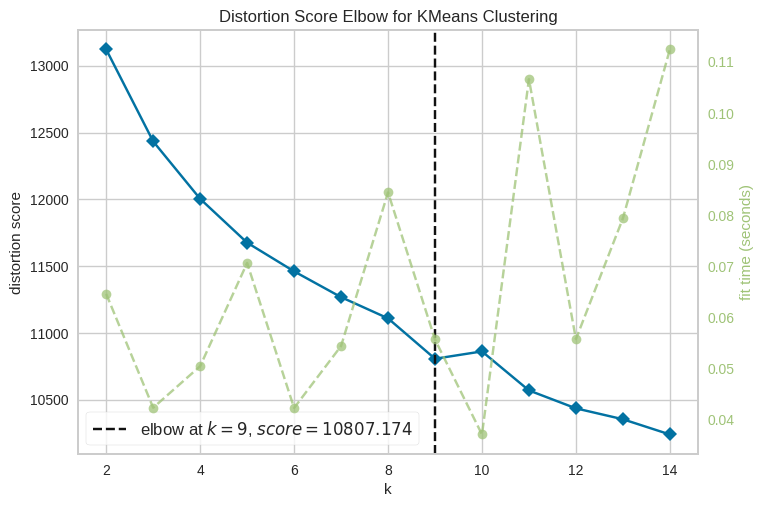

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [12]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

scaler = MinMaxScaler(feature_range=(0,1))
df_r_scaled = scaler.fit_transform(df_r)

kmeans = KMeans()
visualizer = KElbowVisualizer(kmeans, k=(2,15))
visualizer.fit(df_r_scaled)
visualizer.poof()

Según el gráfico 5 es el número idóneo de clústeres, que se corresponderían con 5 personalidades diferentes.

## Aplicar K-Means

In [13]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5)
pred = kmeans.fit(df_r_scaled).labels_
df_r['cluster'] = pred

In [14]:
df_r.head()

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,OPN2,OPN3,OPN4,OPN5,OPN6,OPN7,OPN8,OPN9,OPN10,cluster
364189,2.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,...,3.0,3.0,4.0,3.0,2.0,3.0,2.0,3.0,3.0,2
643435,4.0,1.0,4.0,4.0,4.0,1.0,0.0,2.0,4.0,4.0,...,2.0,4.0,1.0,4.0,2.0,2.0,4.0,4.0,4.0,1
149321,1.0,5.0,3.0,3.0,1.0,2.0,1.0,4.0,2.0,4.0,...,1.0,5.0,1.0,5.0,1.0,4.0,1.0,5.0,4.0,0
5452,2.0,4.0,3.0,3.0,3.0,3.0,3.0,4.0,4.0,2.0,...,3.0,3.0,3.0,3.0,3.0,4.0,2.0,4.0,3.0,2
119911,3.0,2.0,4.0,2.0,5.0,2.0,4.0,1.0,1.0,1.0,...,1.0,4.0,2.0,3.0,2.0,4.0,1.0,3.0,3.0,4


## Analizando los resultados

Lo que vamos a hacer es calcular el valor medio para cada una de las áreas por persona. Y luego el valor medio de dicho dato para todas las personas del clúster.

In [15]:
col_list = list(df_r)
ext = col_list[0:10]
est = col_list[10:20]
agr = col_list[20:30]
csn = col_list[30:40]
opn = col_list[40:50]

df_sumas = pd.DataFrame()
df_sumas['extroversion'] = df_r[ext].sum(axis=1)/10
df_sumas['neurotic'] = df_r[est].sum(axis=1)/10
df_sumas['agreeable'] = df_r[agr].sum(axis=1)/10
df_sumas['conscientious'] = df_r[csn].sum(axis=1)/10
df_sumas['open'] = df_r[opn].sum(axis=1)/10
df_sumas['cluster'] = pred

In [16]:
df_sumas.head()

,extroversion,neurotic,agreeable,conscientious,open,cluster
364189,3.1,3.2,3.1,3.3,2.9,2
643435,2.8,2.9,3.0,3.2,3.2,1
149321,2.6,2.0,2.6,2.3,2.9,0
5452,3.1,3.3,3.0,3.1,3.0,2
119911,2.5,2.5,3.3,3.0,2.6,4


In [20]:
# Hallamos las medias para cada cluster
df_sumas.groupby('cluster').mean()

,extroversion,neurotic,agreeable,conscientious,open
cluster,,,,,
0,2.925092,2.471464,2.847724,2.890775,3.067159
1,3.081835,3.415138,3.307798,3.216514,3.333761
2,2.955787,3.640146,3.139103,3.174974,3.232534
3,3.035135,3.011004,3.166409,3.154826,3.261680
4,3.085806,2.484799,3.226923,3.117399,3.341026


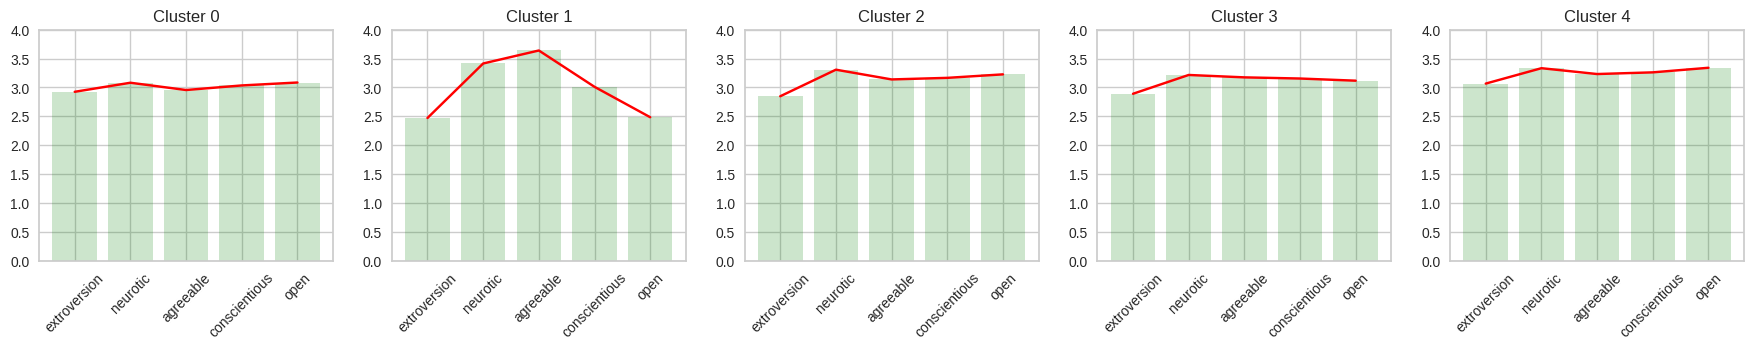

In [21]:
# Visualizamos los 5 perfiles
dataclusters = df_sumas.groupby('cluster').mean()
plt.figure(figsize=(22,3))
for i in range(0, 5):
    plt.subplot(1,5,i+1)
    plt.bar(dataclusters.columns, dataclusters.iloc[:, i], color='green', alpha=0.2)
    plt.plot(dataclusters.columns, dataclusters.iloc[:, i], color='red')
    plt.title('Cluster ' + str(i))
    plt.xticks(rotation=45)
    plt.ylim(0,4);

## Visualizando los resultados

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

df_pca = pd.DataFrame(data=pca.fit_transform(df_r_scaled), columns=['PCA1', 'PCA2'])
df_pca['Clusters'] = pred
df_pca.head()

,PCA1,PCA2,Clusters
0,-0.505459,-0.028224,2
1,0.018696,0.593105,1
2,0.209901,-1.229223,0
3,-0.371837,0.062561,2
4,0.939040,-0.426859,4


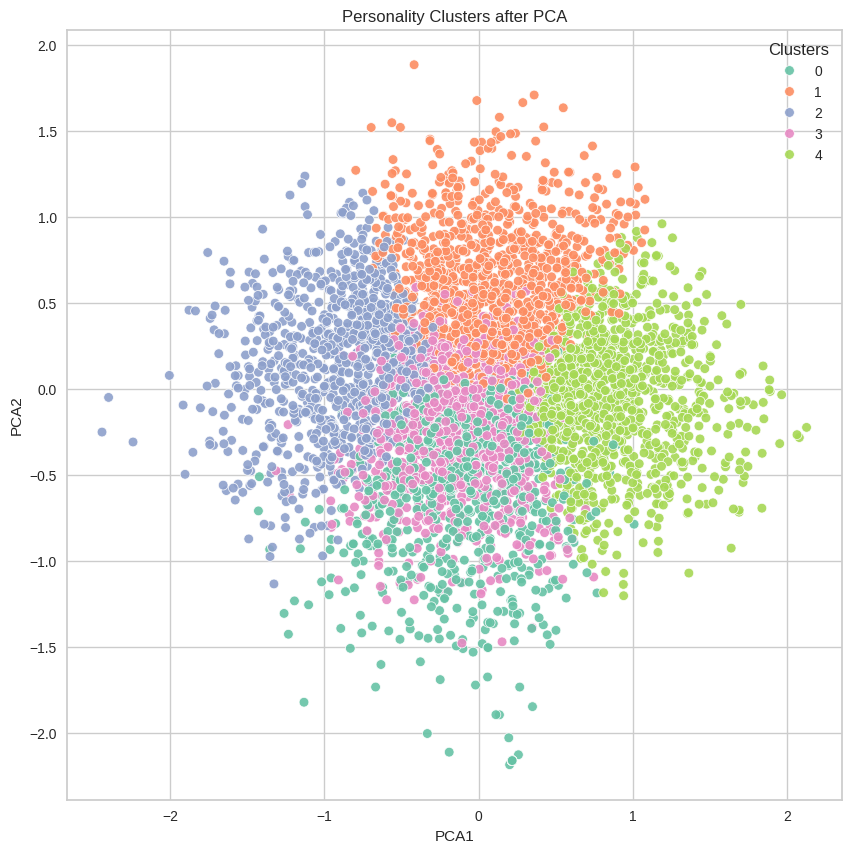

In [23]:
plt.figure(figsize=(10,10))
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='Clusters', palette='Set2', alpha=0.9)
plt.title('Personality Clusters after PCA');

In [ ]:
df_r.tail(2)

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,OPN2,OPN3,OPN4,OPN5,OPN6,OPN7,OPN8,OPN9,OPN10,cluster
560022,3.0,2.0,2.0,4.0,4.0,1.0,1.0,5.0,1.0,4.0,...,1.0,4.0,1.0,5.0,3.0,4.0,5.0,5.0,5.0,1
682408,2.0,3.0,4.0,2.0,4.0,3.0,3.0,3.0,4.0,2.0,...,2.0,4.0,3.0,5.0,2.0,5.0,3.0,3.0,4.0,1


## Haciendo predicciones

In [ ]:
datos = [[3, 2, 2, 4, 4, 1, 1, 2, 5, 2, 3, 1, 2, 4, 1, 4, 3, 2, 5, 2,
         3, 1, 1, 2, 3, 1, 5, 2, 1, 2, 3, 2, 2, 1, 1, 2, 3, 5, 2, 2,
         1, 3, 3, 4, 3, 1, 3, 3, 4, 2]]
mis_datos = pd.DataFrame(datos)
mi_pred = kmeans.predict(mis_datos)
mi_pred

array([4], dtype=int32)